
## Minimum Norm Solution






## Inputs



(2, 'i_h2i_rate')

(3, 'i_pci_rate')

(5, 'i_ngi_rate')

(6, 'i_o2_volfract')

(8, 'i_h2_temp')

(9, 'i_hbtemp')

(10, 'i_wind_rt')


## Outputs


* desired output requirements 


(27, 'o_tgt')

(29, 'o_hmt')

(39, 'o_prod_rt')

(40, 'o_fta')

(28, 'o_coke_rt')



In [1]:

## !pip install xgboost
## !pip install onnxmltools
## !pip install onnxruntime
## !pip install pandas
## !pip install scikit-learn
## !pip install matplotlib
## !pip install seaborn
## !pip install mlxtend
## ! pip install skl2onnx



In [2]:


import torch
import numpy as np
import pandas as pd
import sklearn
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import math
import seaborn as sns
import random
import functorch


import torch.optim as optim


from numpy.random import normal
from scipy.stats import norm
import scipy.stats as stats
from numpy import hstack
from numpy import vstack
from numpy import exp
from sklearn.neighbors import KernelDensity

##from typing import Optional

from torch import Tensor


from torch.utils.data import TensorDataset, DataLoader

from mlxtend.plotting import heatmap

## coefficient of determination (R**2)
from sklearn.metrics import r2_score

np.set_printoptions(suppress=True)
torch.set_printoptions(sci_mode=False)

import os, json, time, uuid


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score





In [3]:


import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor, DMatrix, train as train_xgb
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import onnxmltools
from onnxmltools.convert.xgboost.operator_converters.XGBoost import (
    convert_xgboost)
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster


from zipfile import ZipFile
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx import convert_sklearn, to_onnx, update_registered_converter
from skl2onnx.common.shape_calculator import (
    calculate_linear_classifier_output_shapes,
    calculate_linear_regressor_output_shapes)


# Import the ONNX runtime environment
import onnxruntime as rt




/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/onnx_ops.py:159: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  tys = obj.typeStr or ''
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/automation.py:154: UserWarning: OpSchema.FormalParameter.isHomogeneous is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.is_homogeneous instead.
  if getattr(obj, 'isHomogeneous', False):
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/jinja2/environment.py:485: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  return getattr(obj, attribute)


In [4]:

import PDFshapingUtils as PDF_tk


In [5]:

PDFshapingOBJ = PDF_tk.PDFshapingUtils()


In [6]:

PDFshapingOBJ.read_csv_file_with_pandas('CFD.16.2025.csv')


In [7]:

## Ty suggested fix where 0 needs to be 300

PDFshapingOBJ.CFD_raw_data["i_h2_temp"] = PDFshapingOBJ.CFD_raw_data["i_h2_temp"].replace(0, 300)


In [8]:

PDFshapingOBJ.CFD_raw_data


,index,case name,i_h2i_rate,i_pci_rate,i_wpi_rate,i_ngi_rate,i_o2_volfract,i_ng_temp,i_h2_temp,i_hbtemp,...,o_h2o_sollos,o_feo_sollos,o_hm_rt,o_mw_rt,o_wf_rt,o_hm_h2share,o_mw_h2share,o_wf_h2share,o_prod_rt,o_fta
0,1,H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HB...,0,0,0,120,21,300,300,1200,...,20.0,44.9,122.0,264.0,687.0,31.6,26.7,63.5,4050.0,1800.0
1,2,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,18.5,52.6,122.0,265.0,684.0,27.9,23.4,60.6,4060.0,1850.0
2,3,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.6,50.9,123.0,266.0,690.0,27.7,23.5,60.8,4080.0,1850.0
3,4,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.2,124.0,268.0,690.0,27.7,23.2,60.6,4090.0,1850.0
4,5,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.4,124.0,268.0,695.0,27.7,23.2,60.7,4110.0,1850.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,4995,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,18.7,40.3,353.0,763.0,2190.0,34.0,20.5,56.7,11700.0,2380.0
4995,4996,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,18.7,40.7,353.0,763.0,2190.0,33.8,20.4,56.8,11700.0,2310.0
4996,4997,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,19.2,37.5,353.0,763.0,2230.0,33.6,20.4,57.1,11700.0,2380.0
4997,4998,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,17.6,39.8,355.0,768.0,2220.0,34.0,20.0,55.7,11800.0,2310.0


In [9]:

PDFshapingOBJ.print_headers_list()


['index', 'case name', 'i_h2i_rate', 'i_pci_rate', 'i_wpi_rate', 'i_ngi_rate', 'i_o2_volfract', 'i_ng_temp', 'i_h2_temp', 'i_hbtemp', 'i_wind_rt', 'i_blastH2O', 'i_BdnH2O', 'i_sgi_rate', 'i_sgtemp', 'i_sgi_H2COratio', 'i_sgi_ReProRatio', 'o_tuy_velo', 'o_tuy_temp', 'o_burn', 'o_delp', 'o_co_vf', 'o_co2_vf', 'o_h2_vf', 'o_n2_vf', 'o_co_util', 'o_h2_util', 'o_tgt', 'o_coke_rt', 'o_hmt', 'o_co2_sollos', 'o_h2o_sollos', 'o_feo_sollos', 'o_hm_rt', 'o_mw_rt', 'o_wf_rt', 'o_hm_h2share', 'o_mw_h2share', 'o_wf_h2share', 'o_prod_rt', 'o_fta']
41
(0, 'index')
(1, 'case name')
(2, 'i_h2i_rate')
(3, 'i_pci_rate')
(4, 'i_wpi_rate')
(5, 'i_ngi_rate')
(6, 'i_o2_volfract')
(7, 'i_ng_temp')
(8, 'i_h2_temp')
(9, 'i_hbtemp')
(10, 'i_wind_rt')
(11, 'i_blastH2O')
(12, 'i_BdnH2O')
(13, 'i_sgi_rate')
(14, 'i_sgtemp')
(15, 'i_sgi_H2COratio')
(16, 'i_sgi_ReProRatio')
(17, 'o_tuy_velo')
(18, 'o_tuy_temp')
(19, 'o_burn')
(20, 'o_delp')
(21, 'o_co_vf')
(22, 'o_co2_vf')
(23, 'o_h2_vf')
(24, 'o_n2_vf')
(25, 'o_co_ut

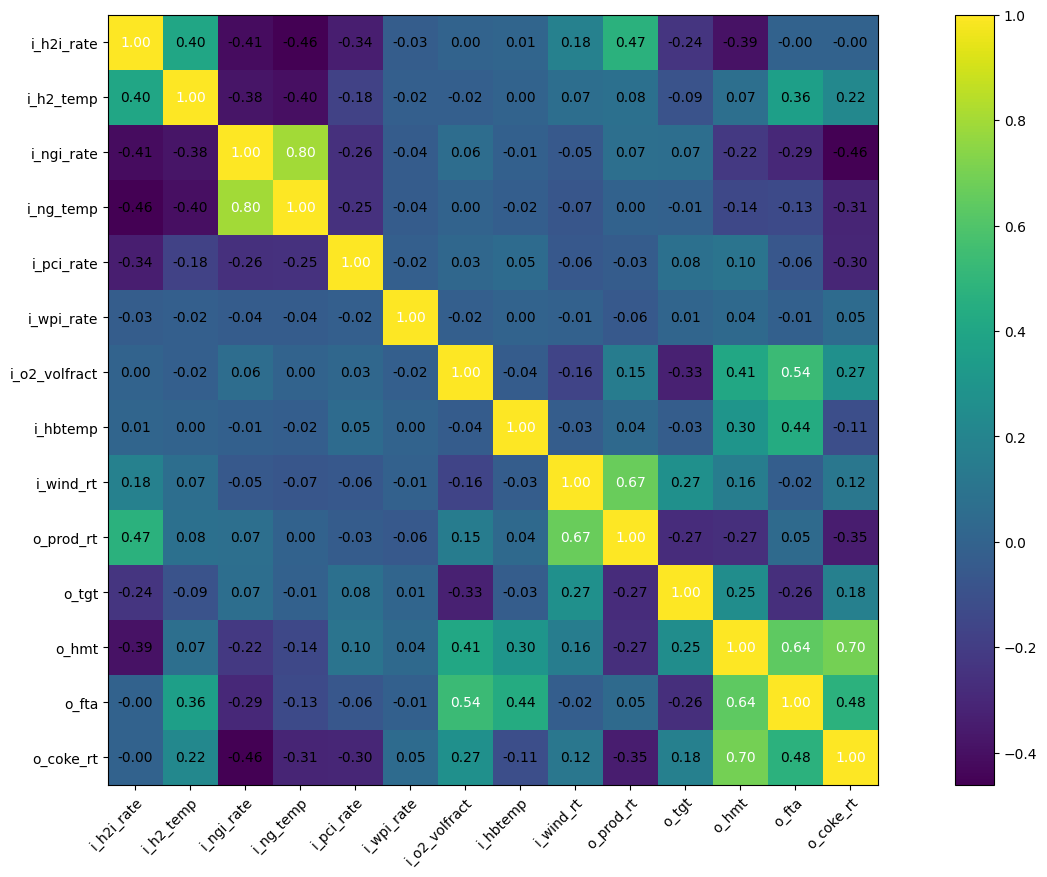

In [10]:


PDFshapingOBJ.list_of_selected_column_names = ['i_h2i_rate','i_h2_temp','i_ngi_rate','i_ng_temp','i_pci_rate',
                    'i_wpi_rate','i_o2_volfract',
                    'i_hbtemp','i_wind_rt','o_prod_rt', 'o_tgt', 'o_hmt','o_fta', 'o_coke_rt']


PDFshapingOBJ.print_correlation_coefficients()


In [11]:

PDFshapingOBJ.convert_pd_data_to_numpy()


[[1
  'H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-7_SGI-0_SGT-0_SGC_0 '
  0 ... 63.5 4050.0 1800.0]
 [2
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-1_SGI-0_SGT-0_SGC_0 '
  0 ... 60.6 4060.0 1850.0]
 [3
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  0 ... 60.8 4080.0 1850.0]
 ...
 [4997
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1600_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 57.1 11700.0 2380.0]
 [4998
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-3_SGI-0_SGT-0_SGC_0 '
  30 ... 55.7 11800.0 2310.0]
 [4999
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 56.2 11800.0 2310.0]]
(4999, 41)


In [12]:

PDFshapingOBJ.gen_X_y_for_selected_indeces(  
                   inputs = [  2, 3, 5, 6, 8, 9, 10   ] , 
                   outputs= [ 27, 29, 39, 40, 28 ]   
)


## inputs = [ 2, 3, 5, 6, 8, 9, 10  ]          ## the full 7



7
5


In [13]:

print(PDFshapingOBJ.X.shape)
print(PDFshapingOBJ.y.shape)


(4999, 7)
(4999, 5)


In [14]:

PDFshapingOBJ.random_seed = int( random.random() * 100  )         ## defautl is 42


In [15]:

PDFshapingOBJ.split_np_data_train_test(selected_test_size=0.2)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [16]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [17]:

from sklearn.decomposition import PCA

# Instantiate PCA to reduce to 5 components
pca = PCA(n_components=5)

# Fit on training data and transform both train and test
X_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)
X_test_pca  = pca.transform(PDFshapingOBJ.X_test)

# Replace the original inputs with PCA-reduced versions
PDFshapingOBJ.X_train = X_train_pca
PDFshapingOBJ.X_test  = X_test_pca





In [18]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 5)
(1000, 5)
(3999, 5)
(1000, 5)


In [19]:

PDFshapingOBJ.convert_dataset_from_np_to_torch()


In [20]:

PDFshapingOBJ.standardize_X_scales()
PDFshapingOBJ.standardize_y_scales()


In [21]:


PDFshapingOBJ.gen_Dataloader_train()

PDFshapingOBJ.train_dl



## Model Forward ( 7x4 )


In [22]:

n_inputs  = 5     ## 7
n_outputs = 5




#############################################################
##   F1      plus       F2
## Linear     +      Nonlinear

class F1plusF2_SIO_Forward(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations,  device='cuda'):
        super().__init__()
        self.device = device
        
        ## self.x_means      = x_means
        ## self.x_deviations = x_deviations
        ## self.y_means      = y_means
        ## self.y_deviations = y_deviations
        
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)
        
        
        
        ## F1
        self.f1_linear1 = nn.Linear(n_inputs, n_outputs)       
        
        ## F2
        self.f2_linear1 = nn.Linear(n_inputs, 10)
        self.f2_act1    = nn.Sigmoid()                    ## Tanh()                       
        self.f2_linear2 = nn.Linear(10, n_outputs)       
        self.f2_dropout = nn.Dropout(0.25)
        
        # Move model to device
        self.to(self.device)
        
        
    ## perform inference
    def forward(self, x):
        x = x.to(self.device)
        x = (x - self.x_means) / self.x_deviations
        
        ## F1
        f1 = self.f1_linear1(x)
        
        ## F2
        f2 = self.f2_linear1(x)
        f2 = self.f2_act1(f2)
        f2 = self.f2_dropout(f2)
        f2 = self.f2_linear2(f2)
        
        
        y_scaled   = f1 + f2
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        ##   y_descaled = torch.clamp(  y_descaled, min=0.0  )
        
        return y_descaled, y_scaled
    




In [23]:

n_inputs  = 5     ## 7
n_outputs = 5





    
class ResidualNet_Forward(nn.Module):
    def __init__(self, x_means, x_deviations, y_means, y_deviations, dropout_rate=0.1, device='cuda'):
        
        super().__init__()
        self.device = device
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)

     
        self.fc1  = nn.Linear(n_inputs, 64)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(64, 64)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(64, n_outputs)

        # If input_dim ≠ 64, project for residual addition
        self.input_proj = nn.Linear(n_inputs, 64) if n_inputs != 64 else nn.Identity()
        
        # Move model to device
        self.to(self.device)
        

    def forward(self, x):
        x  = x.to(self.device)
        x  = (x - self.x_means) / self.x_deviations
        x0 = self.input_proj(x)
        x1 = self.dropout1(self.act1(self.fc1(x)))
        x2 = self.dropout2(self.act2(self.fc2(x1)))
        x_res = x2 + x0
        y_scaled = self.fc3(x_res)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    

    


In [24]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## model_Forward     = F1plusF2_SIO_Forward(

model_Forward     =     F1plusF2_SIO_Forward(
                         PDFshapingOBJ.x_means, 
                         PDFshapingOBJ.x_deviations, 
                         PDFshapingOBJ.y_means, 
                         PDFshapingOBJ.y_deviations,
                         device=device  # pass device into the model
    
)

optimizer = optim.Adam(model_Forward.parameters(), lr=0.001)
loss_fn   = nn.MSELoss()



In [25]:

model_Forward.train()

for epoch in range(1000):
    for xb, yb in PDFshapingOBJ.train_dl:
        
        xb = xb.to(model_Forward.device)
        yb = yb.to(model_Forward.device)
        
        optimizer.zero_grad()
        pred_descaled, pred_scaled = model_Forward(xb)
        loss = loss_fn(pred_scaled, yb)
        loss.backward()
        optimizer.step()
    if epoch % 100 == 0:
        print(epoch, ".....", loss.item() ) 
    



0 ..... 0.8192874193191528
100 ..... 0.7098628878593445
200 ..... 0.45393866300582886
300 ..... 0.5926098823547363
400 ..... 0.3452591001987457
500 ..... 0.7931550145149231
600 ..... 0.3280978500843048
700 ..... 0.9897778034210205
800 ..... 0.560249924659729
900 ..... 0.5299490094184875


In [26]:

print("=== SANITY CHECK: SCALING ===")
print("y_means:", PDFshapingOBJ.y_means)
print("y_deviations:", PDFshapingOBJ.y_deviations)

print("===============================================")

print("x_means:", PDFshapingOBJ.x_means)
print("x_deviations:", PDFshapingOBJ.x_deviations)


=== SANITY CHECK: SCALING ===
y_means: tensor([[  97.7332, 1305.5582, 8429.6494, 2309.6619,  417.5223]])
y_deviations: tensor([[  50.6673,  523.4216, 1515.7469,  211.0726,   49.7891]])
x_means: tensor([[    -0.0000,     -0.0000,     -0.0000,     -0.0000,      0.0000]])
x_deviations: tensor([[272.7812, 156.1632,  51.1471,  35.9892,  26.3943]])


In [27]:

print(PDFshapingOBJ.y_means -  PDFshapingOBJ.y_deviations)
print(PDFshapingOBJ.y_means +  PDFshapingOBJ.y_deviations)


tensor([[  47.0659,  782.1367, 6913.9023, 2098.5894,  367.7332]])
tensor([[ 148.4005, 1828.9797, 9945.3965, 2520.7344,  467.3114]])


In [28]:

print(PDFshapingOBJ.x_means -  PDFshapingOBJ.x_deviations)
print(PDFshapingOBJ.x_means +  PDFshapingOBJ.x_deviations)


tensor([[-272.7812, -156.1632,  -51.1471,  -35.9892,  -26.3943]])
tensor([[272.7812, 156.1632,  51.1471,  35.9892,  26.3943]])



## Is model  invertible ?

* use the Jacobian


In [29]:

import torch
from torch.autograd.functional import jacobian


In [30]:

## x = torch.randn(1, 7, requires_grad=True)

x = torch.randn(      7, requires_grad=True)  # shape [7]

x = torch.randn(      5, requires_grad=True)  # shape [7]


In [31]:

def wrapped_model(x):
    y_descaled, _ = model_Forward(x)
    return y_descaled  # Only return 1 tensor to get a clean Jacobian




In [32]:

## J = jacobian(model_Forward, x)

J = jacobian(wrapped_model, x)


In [33]:

print( len(J) )


1


In [34]:


print( J.shape )  # Should be [1, 4, 7]


torch.Size([1, 5, 5])


In [35]:

u, s, v = torch.svd(J)  


In [36]:

rank = (s > 1e-5).sum()


In [37]:


print("Local Jacobian rank:", rank.item())


Local Jacobian rank: 5



## Approach


In [66]:

import numpy as np
from numpy.linalg import norm

# --- distance function ---
def euclid(a, b):
    return norm(a - b)



## Now add Costs


In [67]:

price_real = np.array([4.0, 1.0, 0.5, 0.0, 0.0, 0.0, 0.0])

price_latent = pca.components_ @ price_real

price_latent = torch.tensor(price_latent, dtype=torch.float32)


In [80]:



def solve_minimum_norm_update(x0, y_min, y_max):

    x = x0.detach().clone().requires_grad_(True)
    J = jacobian(wrapped_model, x, create_graph=True, vectorize=True)
    current_y = wrapped_model(x)
    
 
    delta_y = torch.relu(y_min - current_y) - torch.relu(current_y - y_max)

    
  
    
    print( J.shape )
    
    if J.dim() > 2:
        J = J.view(-1, x.numel())
        delta_y = delta_y.view(-1)
        
        
    U, S, Vt = torch.linalg.svd(J)
    S_new = S / (S**2 + 1.0)   # <-- key change
    J_reg = Vt.T @ torch.diag(S_new) @ U.T

    lambda_cost = 0.01   ## 0.01

    delta_x = ( J_reg @ delta_y) - lambda_cost * price_latent
    
    ## delta_x = 0.01 * delta_x
    delta_x = delta_x.view_as(x0)
    return delta_x






In [81]:


x_starting_point = torch.tensor(   PDFshapingOBJ.X_test[0]   )    ## starting point

dist_method_A = []
dist_method_B = []

cost_diffs    = [] 
cost_diff     = 0

percent_diffs = []
percent_diff  = 0 


for i in range(  1, PDFshapingOBJ.X_test.shape[0]  ):
    
    ## target_y  = torch.tensor( PDFshapingOBJ.y_test[i]   )    ## what you want y ?
    
    y_real  = torch.tensor(PDFshapingOBJ.y_test[i]).float().unsqueeze(0)
    pct_tol = 0.30
    y_min = y_real * (1 - pct_tol)
    y_max = y_real * (1 + pct_tol)
    
    x_real    = torch.tensor( PDFshapingOBJ.X_test[i]   )    ## real x
    
    x_temp    = x_starting_point
    
    for j in range(5):
        
        delta_x  = solve_minimum_norm_update( x_temp, y_min, y_max )        ##, target_y )
        
        ################################################
        
        x_temp = x_temp + delta_x

        # clamp in PCA space (simple version)
        #x_temp = torch.clamp(x_temp, min=-3.0, max=3.0)
        
        ###############################################
        
        # ---- compute cost at this iteration ----
        x_temp_np   = x_temp.detach().numpy()
        x_temp_real = pca.inverse_transform(x_temp_np)

        # enforce physical constraint
        x_temp_real = np.maximum(x_temp_real, 0.0)

        cost = np.dot(price_real, x_temp_real)
        
        x_real_np         = x_real.detach().numpy()
        x_real_np_sol     = pca.inverse_transform( x_real_np  ) 
        cost_real         = np.dot(price_real, x_real_np_sol)
       
        print(f"iteration {j} cost: {cost}...H2, PCI, NGI:", x_temp_real[:3] )
        print("real cost       :", cost_real)
        cost_diff    = cost - cost_real
        percent_diff = (cost - cost_real) / cost_real
        
    percent_diffs.append( percent_diff  )
          
    cost_diffs.append(       cost_diff  )
        
 
    x_new             = x_temp  
    
    x_new_np          =  x_new.detach().numpy()
    x_real_np         = x_real.detach().numpy()
    
    x_new_solution    = pca.inverse_transform( x_new_np   )
    x_real_np_sol     = pca.inverse_transform( x_real_np  ) 
    
    
    # enforce physical constraint
    x_new_solution = np.maximum(x_new_solution, 0.0)
    x_real_np_sol  = np.maximum(x_real_np_sol,  0.0)
    
    
    the_cols = "    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    

    print("...")
    print("...")
    print("...")
    print( the_cols )
    print( "pred x" )
    print( x_new_solution )
    print( "real x" )
    print( x_real_np_sol )
    
    ##########################################
    
    
    x_new_solution = np.atleast_2d(x_new_solution)
    x_real_np_sol  = np.atleast_2d(x_real_np_sol)

    x_new_pca  = pca.transform(x_new_solution)
    x_real_pca = pca.transform(x_real_np_sol)

    y_pred_rc = wrapped_model(torch.tensor(x_new_pca).float())
    y_real_rc = wrapped_model(torch.tensor(x_real_pca).float())
    
    
    ##########################################
    
    the_cols_y = "o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt"
        
    print( the_cols_y )
    print( "pred y" )
    print( y_pred_rc )
    print( "real y" )
    print( y_real_rc )
    
    
    dist_method_A.append( euclid(x_new_np, x_real_np) )
    dist_method_B.append( euclid(
            y_pred_rc.detach().numpy(),
            y_real_rc.detach().numpy()
    ))
    
    print(i)
    print('********************************')
    
    ##########################################
    
    if i == 1:
        percent_errors = [[] for _ in range(5)]  # one list per output

    y_pred_np = y_pred_rc.detach().numpy().flatten()
    y_real_np = y_real_rc.detach().numpy().flatten()

    # % error per variable
    pct = (y_pred_np - y_real_np) / (y_real_np + 1e-8) * 100

    for k in range(5):
         percent_errors[k].append(pct[k])




torch.Size([1, 5, 5])
iteration 0 cost: 92.81463547841537...H2, PCI, NGI: [12.41028108 31.94722475 22.45257278]
real cost       : 55.60858691193641
torch.Size([1, 5, 5])
iteration 1 cost: 92.78619591356043...H2, PCI, NGI: [12.32765095 32.07090389 22.80937645]
real cost       : 55.60858691193641
torch.Size([1, 5, 5])
iteration 2 cost: 92.69651971325588...H2, PCI, NGI: [12.23649317 32.09046578 23.32016253]
real cost       : 55.60858691193641
torch.Size([1, 5, 5])
iteration 3 cost: 92.72708627324798...H2, PCI, NGI: [12.15876301 32.32140299 23.54126249]
real cost       : 55.60858691193641
torch.Size([1, 5, 5])
iteration 4 cost: 92.75416647505425...H2, PCI, NGI: [12.0896256  32.52678627 23.73775565]
real cost       : 55.60858691193641
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred x
[  12.0896256    32.52678627   23.73775565   25.61077384  299.83809009
 1484.60393967  193.62459191]
real x
[   0.            0.          119.8187596

torch.Size([1, 5, 5])
iteration 4 cost: 84.00679481670772...H2, PCI, NGI: [12.7655884  23.72482005 18.43924233]
real cost       : 65.38424754564927
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred x
[  12.7655884    23.72482005   18.43924233   25.91349295  292.71444797
 1474.62594235  175.38848501]
real x
[   8.35388233    1.28854177   61.36035289   26.21287218  299.93573187
 1599.97586731  159.41731322]
o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
pred y
tensor([[  92.1287, 1643.0850, 6757.1069, 2425.2949,  456.5169]],
       grad_fn=<AddBackward0>)
real y
tensor([[  81.6471, 1401.0732, 6728.0688, 2406.7156,  413.9028]],
       grad_fn=<AddBackward0>)
42
********************************
torch.Size([1, 5, 5])
iteration 0 cost: 98.21836884322583...H2, PCI, NGI: [11.46167398 37.84614188 29.0510621 ]
real cost       : 125.1131722671156
torch.Size([1, 5, 5])
iteration 1 cost: 99.00333610378993...H2, PCI, NGI: [11.44149831 39.03541317

torch.Size([1, 5, 5])
iteration 4 cost: 98.21398616853993...H2, PCI, NGI: [12.04925899 43.03233599 13.96922839]
real cost       : 85.66192026596418
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred x
[  12.04925899   43.03233599   13.96922839   25.60061567  298.50665612
 1477.13328487  193.83726116]
real x
[  15.37134491    2.4011164    43.55084844   25.23281645  299.883197
 1199.94471981  228.71622561]
o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
pred y
tensor([[ 111.9241, 1763.5913, 7311.4502, 2412.8354,  454.0329]],
       grad_fn=<AddBackward0>)
real y
tensor([[ 132.4090, 1561.8105, 8474.9180, 2221.9736,  473.5340]],
       grad_fn=<AddBackward0>)
90
********************************
torch.Size([1, 5, 5])
iteration 0 cost: 92.0795828799234...H2, PCI, NGI: [12.49331937 30.35930399 23.49400286]
real cost       : 77.70355096144394
torch.Size([1, 5, 5])
iteration 1 cost: 91.75224134632114...H2, PCI, NGI: [12.47173947 29.77056658 24

iteration 4 cost: 129.5070262977449...H2, PCI, NGI: [ 0.         96.00132335 67.01140589]
real cost       : 101.21741152573415
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred x
[   0.           96.00132335   67.01140589   26.08294174  333.47973948
 1480.5039084   187.53848967]
real x
[  26.68909865    0.            0.           24.99840234  600.17812423
 1200.07649003  231.80375612]
o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
pred y
tensor([[ 102.4595, 1203.1359, 8379.7695, 2265.6526,  355.1084]],
       grad_fn=<AddBackward0>)
real y
tensor([[  96.8796, 1244.7379, 9782.2920, 2265.8384,  455.1715]],
       grad_fn=<AddBackward0>)
133
********************************
torch.Size([1, 5, 5])
iteration 0 cost: 132.71509966265225...H2, PCI, NGI: [ 0.         97.36197314 70.70625305]
real cost       : 105.48256539979012
torch.Size([1, 5, 5])
iteration 1 cost: 132.71215560830362...H2, PCI, NGI: [ 0.         97.3582158  70.70787963]
rea

torch.Size([1, 5, 5])
iteration 0 cost: 102.92088829373346...H2, PCI, NGI: [ 0.         76.51760809 52.80656041]
real cost       : 96.3637035033416
torch.Size([1, 5, 5])
iteration 1 cost: 102.32027111570878...H2, PCI, NGI: [ 0.         74.71334643 55.21384938]
real cost       : 96.3637035033416
torch.Size([1, 5, 5])
iteration 2 cost: 115.79022794815313...H2, PCI, NGI: [ 0.         82.43388322 66.71268945]
real cost       : 96.3637035033416
torch.Size([1, 5, 5])
iteration 3 cost: 110.02724736379233...H2, PCI, NGI: [ 0.         74.43770234 71.17909005]
real cost       : 96.3637035033416
torch.Size([1, 5, 5])
iteration 4 cost: 107.106993277015...H2, PCI, NGI: [ 0.         69.66482122 74.88434412]
real cost       : 96.3637035033416
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred x
[   0.           69.66482122   74.88434412   26.21864483  327.92848029
 1474.26437722  178.55937282]
real x
[  13.06708746   43.02440126    2.14190483 

...

torch.Size([1, 5, 5])
iteration 1 cost: 101.97162236029416...H2, PCI, NGI: [ 9.03761721 50.32074193 31.00082322]
real cost       : 73.51742305167262
torch.Size([1, 5, 5])
iteration 2 cost: 102.43823490457932...H2, PCI, NGI: [ 8.8171407  51.59752938 31.14428542]
real cost       : 73.51742305167262
torch.Size([1, 5, 5])
iteration 3 cost: 102.435485623609...H2, PCI, NGI: [ 8.81718926 51.59377239 31.14591239]
real cost       : 73.51742305167262
torch.Size([1, 5, 5])
iteration 4 cost: 102.43273634263866...H2, PCI, NGI: [ 8.81723782 51.59001539 31.14753936]
real cost       : 73.51742305167262
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred x
[   8.81723782   51.59001539   31.14753936   25.50299683  311.75232282
 1484.21610079  203.90173489]
real x
[   0.            0.          149.94909284   25.26694108  300.00290084
 1599.99956926  229.99633549]
o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
pred y
tensor([[ 116.6941, 1681.5974, 7925.0

iteration 0 cost: 91.57945355442298...H2, PCI, NGI: [12.51920748 31.92693109 19.1513851 ]
real cost       : 67.93362393145897
torch.Size([1, 5, 5])
iteration 1 cost: 91.3864162401133...H2, PCI, NGI: [12.55667428 31.48286089 19.35371648]
real cost       : 67.93362393145897
torch.Size([1, 5, 5])
iteration 2 cost: 89.05012271937959...H2, PCI, NGI: [12.29422158 27.351102   25.04426879]
real cost       : 67.93362393145897
torch.Size([1, 5, 5])
iteration 3 cost: 88.73761061803103...H2, PCI, NGI: [12.34877496 26.94414005 24.79674145]
real cost       : 67.93362393145897
torch.Size([1, 5, 5])
iteration 4 cost: 88.82897753891771...H2, PCI, NGI: [12.38631734 27.05659416 24.45422802]
real cost       : 67.93362393145897
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred x
[  12.38631734   27.05659416   24.45422802   25.69262332  295.21232366
 1473.00955475  189.17697813]
real x
[   6.59251399    1.02241059   81.08231477   26.02437803  299.94

torch.Size([1, 5, 5])
iteration 2 cost: 93.02367225098607...H2, PCI, NGI: [12.48335772 32.19815285 21.78417702]
real cost       : 74.91998617443554
torch.Size([1, 5, 5])
iteration 3 cost: 93.13219814035318...H2, PCI, NGI: [12.48104822 32.41324375 21.58952303]
real cost       : 74.91998617443554
torch.Size([1, 5, 5])
iteration 4 cost: 93.26023427798633...H2, PCI, NGI: [12.47754783 32.66816164 21.36376263]
real cost       : 74.91998617443554
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred x
[  12.47754783   32.66816164   21.36376263   25.59773605  299.6748973
 1479.56393991  194.06656475]
real x
[  12.28293923    0.           57.08270316   25.61037741  300.13532739
 1480.05852722  196.37858622]
o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
pred y
tensor([[ 102.8030, 1621.0480, 7564.8047, 2378.9363,  442.1371]],
       grad_fn=<AddBackward0>)
real y
tensor([[ 103.2319, 1462.9852, 7948.7729, 2334.5605,  430.9957]],
       grad_fn=<Ad

torch.Size([1, 5, 5])
iteration 0 cost: 97.99377517245634...H2, PCI, NGI: [ 1.56972983 66.89910864 49.63149445]
real cost       : 159.9829356080379
torch.Size([1, 5, 5])
iteration 1 cost: 104.75137449156234...H2, PCI, NGI: [ 0.         78.39393943 52.71487012]
real cost       : 159.9829356080379
torch.Size([1, 5, 5])
iteration 2 cost: 106.94937925203483...H2, PCI, NGI: [ 0.         79.76142805 54.37590241]
real cost       : 159.9829356080379
torch.Size([1, 5, 5])
iteration 3 cost: 107.30277254067283...H2, PCI, NGI: [ 0.         79.95639637 54.69275234]
real cost       : 159.9829356080379
torch.Size([1, 5, 5])
iteration 4 cost: 107.3665350685518...H2, PCI, NGI: [ 0.         80.02853202 54.67600609]
real cost       : 159.9829356080379
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred x
[   0.           80.02853202   54.67600609   26.18367514  322.79086872
 1485.15914641  176.75736113]
real x
[   0.          198.52339296    0.    

...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred x
[  12.48277414   31.91505577   22.05422045   25.59853078  299.90282792
 1479.9601811   194.05360245]
real x
[  23.81303621    0.59243841    0.62772314   24.76106166  299.97087419
 1479.98743512  229.70389153]
o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
pred y
tensor([[ 109.7629, 1749.0541, 7324.6621, 2405.5818,  451.4887]],
       grad_fn=<AddBackward0>)
real y
tensor([[ 120.8670, 1803.0688, 8738.3018, 2400.4126,  484.3618]],
       grad_fn=<AddBackward0>)
987
********************************
torch.Size([1, 5, 5])
iteration 0 cost: 92.88425952115409...H2, PCI, NGI: [12.48258035 31.93008253 22.04771119]
real cost       : 93.52388513556461
torch.Size([1, 5, 5])
iteration 1 cost: 92.88151028017246...H2, PCI, NGI: [12.4826288  31.92632584 22.0493385 ]
real cost       : 93.52388513556461
torch.Size([1, 5, 5])
iteration 2 cost: 92.87876103919085...H2, PCI, NGI: [12.48267724 31.9225691

In [82]:

avg_A = np.mean(dist_method_A)


print("Average Euclidean Distance for Xs:")
print("Method A:", avg_A)


Average Euclidean Distance for Xs:
Method A: 273.02646


In [83]:


avg_B = np.mean(dist_method_B)


print("Average Euclidean Distance for Ys:")
print("Method B:", avg_B)


Average Euclidean Distance for Ys:
Method B: 1278.1229


In [84]:

print("average cost diff:", np.mean(cost_diffs))

print("average percent diff:", np.mean(percent_diffs)*100, "%")


average cost diff: 45.35663872025503
average percent diff: 67.22086430913444 %


In [85]:

better = np.sum(np.array(cost_diffs) < 0)
total  = len(cost_diffs)

print("solver cheaper in:", better/total*100, "% of cases")


solver cheaper in: 26.926926926926924 % of cases


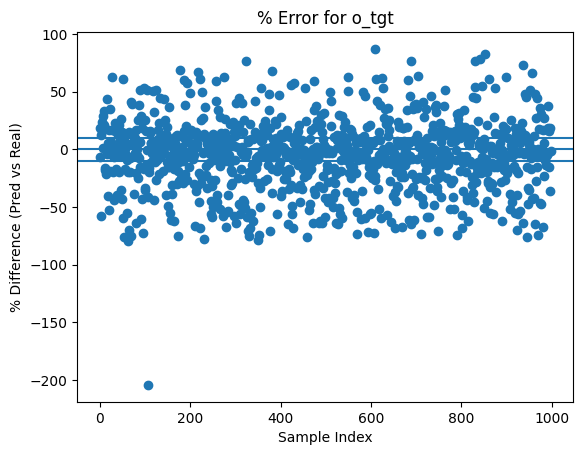

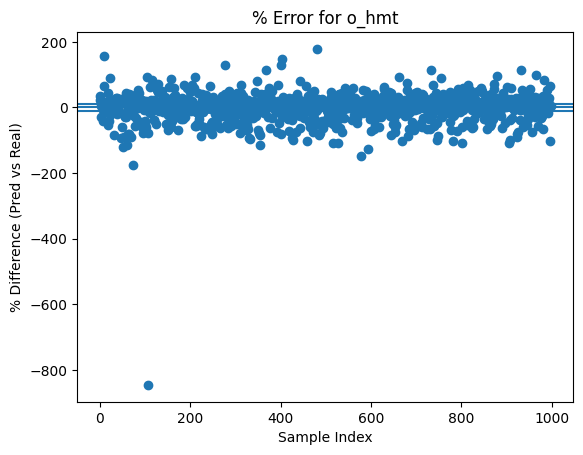

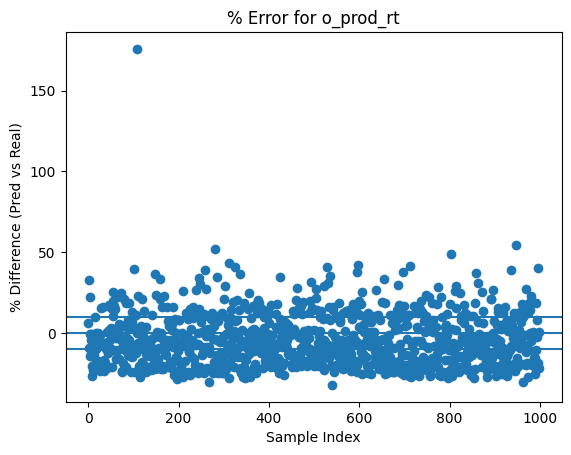

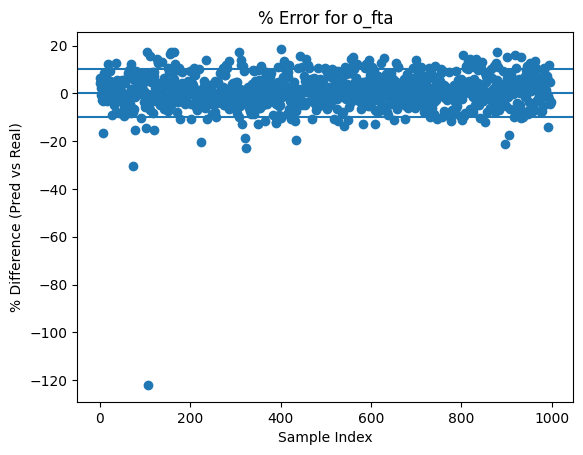

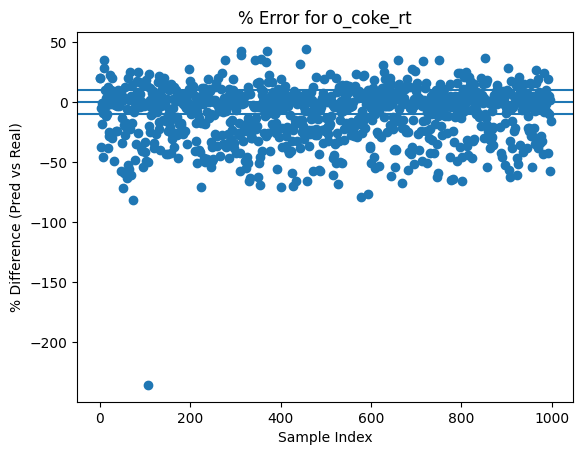

In [86]:

output_names = ['o_tgt', 'o_hmt', 'o_prod_rt', 'o_fta', 'o_coke_rt']

for k in range(5):
    plt.figure()
    plt.scatter(range(len(percent_errors[k])), percent_errors[k])
    
    plt.axhline(0)       # perfect prediction
    plt.axhline(10)      # +10% threshold
    plt.axhline(-10)     # -10% threshold
    
    plt.title(f"% Error for {output_names[k]}")
    plt.xlabel("Sample Index")
    plt.ylabel("% Difference (Pred vs Real)")
    
    plt.show()


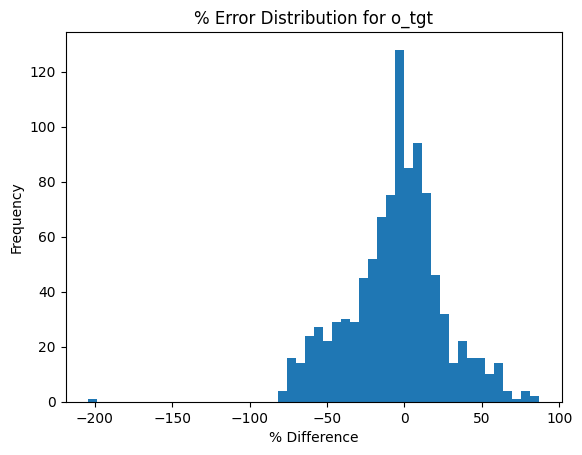

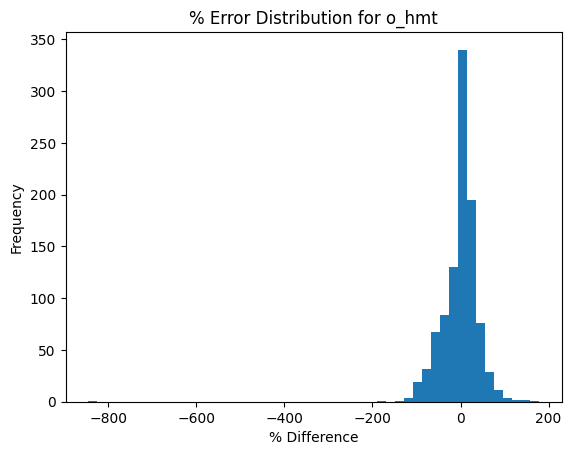

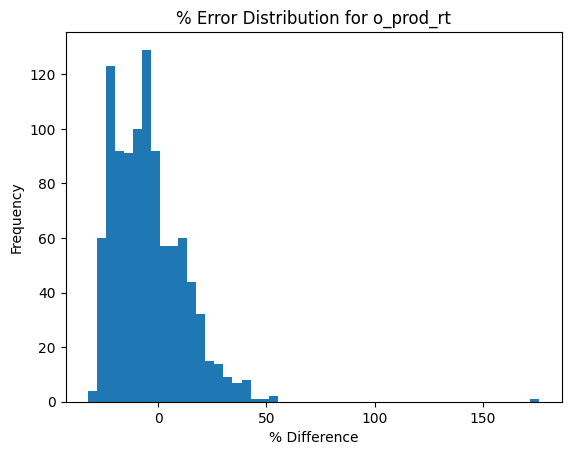

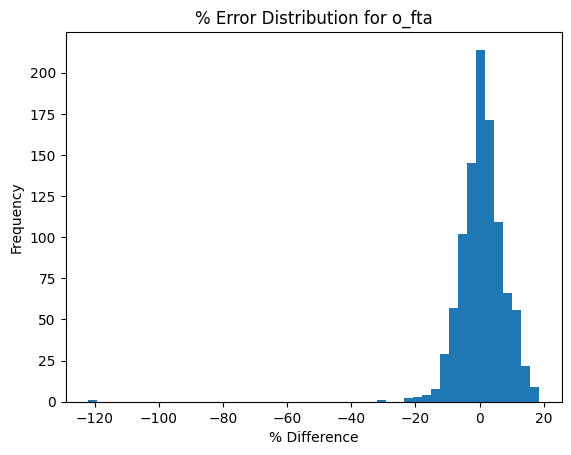

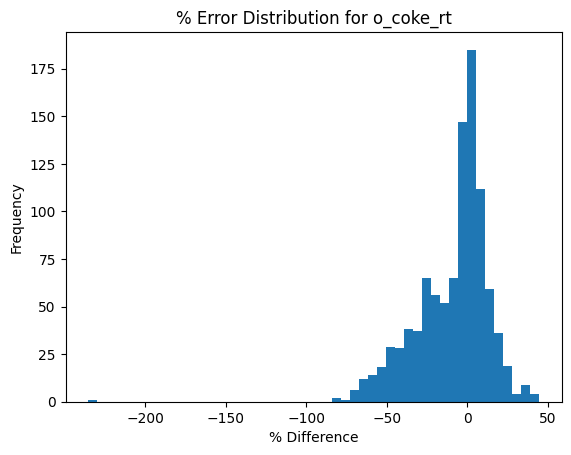

In [87]:

for k in range(5):
    plt.figure()
    plt.hist(percent_errors[k], bins=50)
    plt.title(f"% Error Distribution for {output_names[k]}")
    plt.xlabel("% Difference")
    plt.ylabel("Frequency")
    plt.show()


In [76]:

for k in range(5):
    vals = np.abs(percent_errors[k])
    within_10 = np.mean(vals <= 10) * 100
    within_5  = np.mean(vals <= 5) * 100

    print(output_names[k])
    print("  within 5% :", within_5)
    print("  within 10%:", within_10)


o_tgt
  within 5% : 17.917917917917915
  within 10%: 34.63463463463464
o_hmt
  within 5% : 15.815815815815814
  within 10%: 32.13213213213213
o_prod_rt
  within 5% : 19.81981981981982
  within 10%: 43.14314314314314
o_fta
  within 5% : 59.75975975975976
  within 10%: 87.18718718718719
o_coke_rt
  within 5% : 30.130130130130127
  within 10%: 48.848848848848846


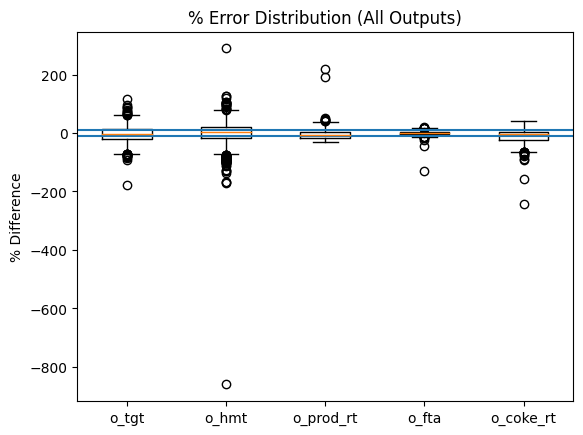

In [77]:

plt.figure()
plt.boxplot(percent_errors)
plt.xticks(range(1,6), output_names)
plt.axhline(10)
plt.axhline(-10)
plt.title("% Error Distribution (All Outputs)")
plt.ylabel("% Difference")
plt.show()


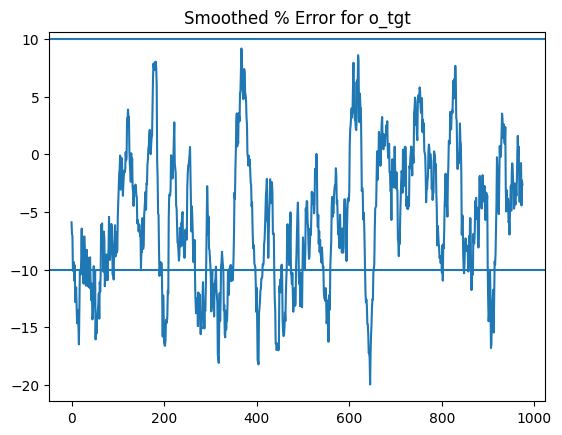

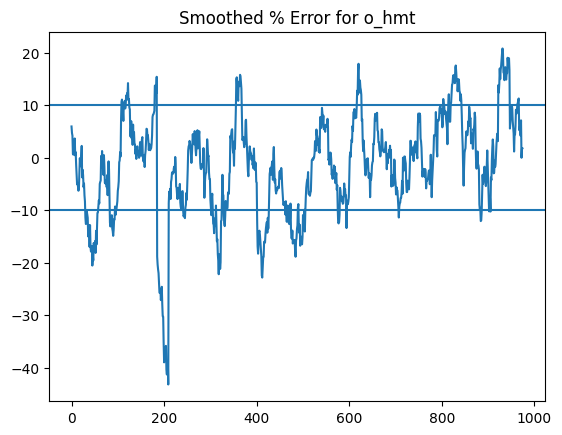

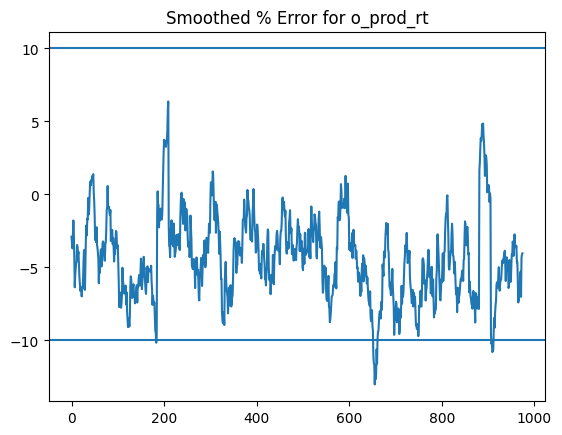

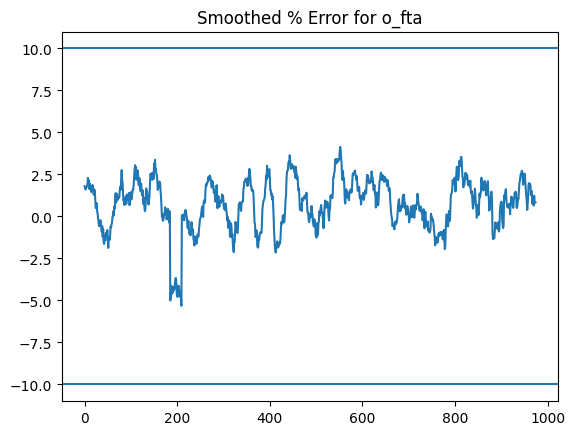

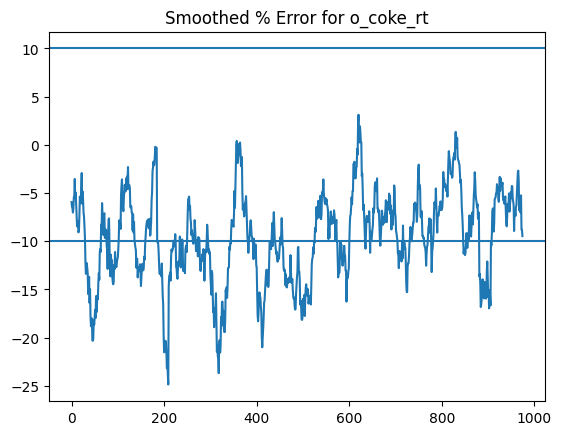

In [78]:

window = 25

for k in range(5):
    vals = np.array(percent_errors[k])
    smooth = np.convolve(vals, np.ones(window)/window, mode='valid')

    plt.figure()
    plt.plot(smooth)
    plt.axhline(10)
    plt.axhline(-10)

    plt.title(f"Smoothed % Error for {output_names[k]}")
    plt.show()


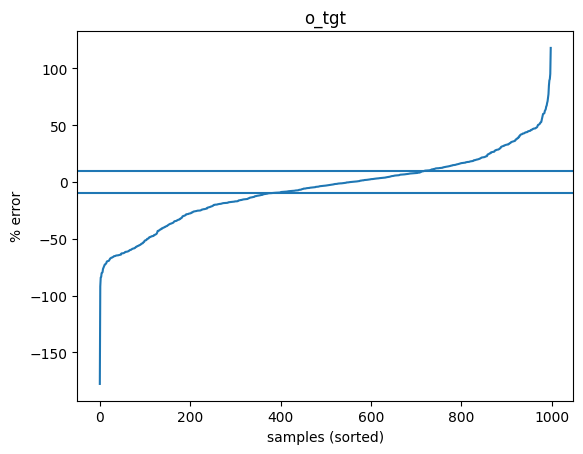

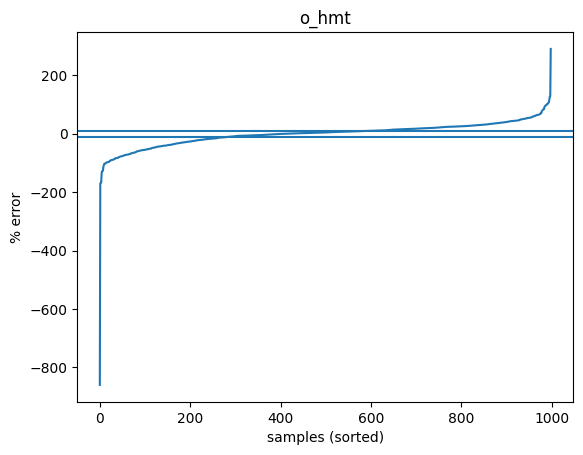

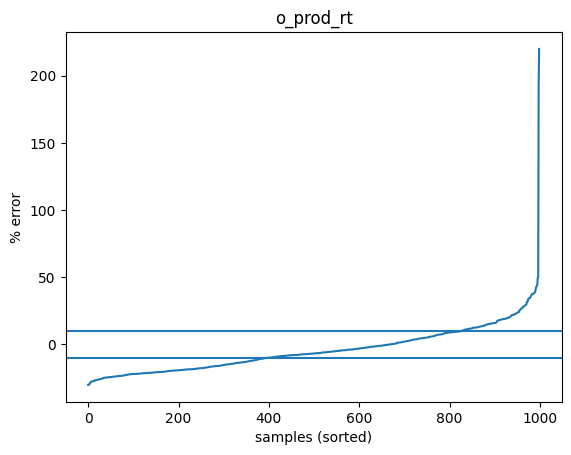

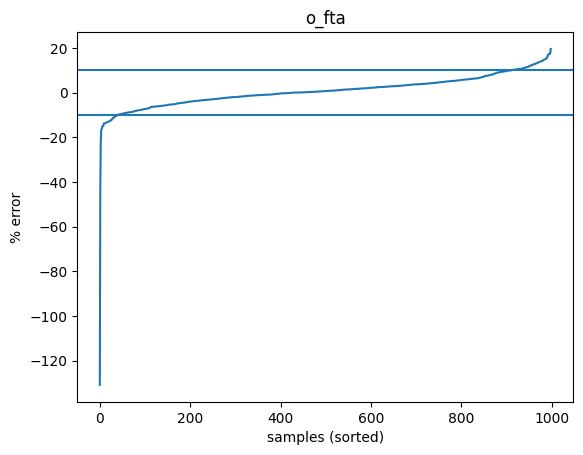

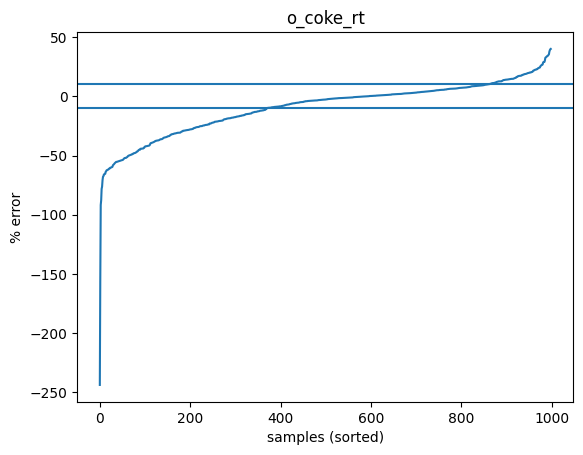

In [79]:

for k in range(5):
    vals = np.sort(np.array(percent_errors[k]))

    plt.figure()
    plt.plot(vals)
    plt.axhline(10)
    plt.axhline(-10)

    plt.title(output_names[k])
    plt.ylabel("% error")
    plt.xlabel("samples (sorted)")
    plt.show()
